In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import sqlite3
import os

print("pandas:", pd.__version__)
print("numpy:", np.__version__)


pandas: 2.2.3
numpy: 2.1.3


In [2]:
DATA_PATH = "../data/"  

# Verify the files are there
files = os.listdir(DATA_PATH)
print(f"Found {len(files)} files:")
for f in sorted(files):
    print(" ·", f)

Found 10 files:
 · olist_customers_dataset.csv
 · olist_geolocation_dataset.csv
 · olist_order_items_dataset.csv
 · olist_order_payments_dataset.csv
 · olist_order_reviews_dataset.csv
 · olist_orders_dataset.csv
 · olist_products_dataset.csv
 · olist_sellers_dataset.csv
 · processed
 · product_category_name_translation.csv


In [3]:
items = pd.read_csv(DATA_PATH+"olist_order_items_dataset.csv")
orders = pd.read_csv(DATA_PATH+"olist_orders_dataset.csv")
products = pd.read_csv(DATA_PATH+"olist_products_dataset.csv")
customers = pd.read_csv(DATA_PATH+"olist_customers_dataset.csv")

print("orders:", orders.shape)
print("items:", items.shape)
print("products:", products.shape)
print("customers:", customers.shape)


orders: (99441, 8)
items: (112650, 7)
products: (32951, 9)
customers: (99441, 5)


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()
print("\n --- items---")
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

 --- items---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 no

In [6]:
# Convert date strings to proper datetime objects
date_cols = [ "order_purchase_timestamp", "order_approved_at", "order_delivered_customer_date", "order_estimated_delivery_date" ] 
for col in date_cols: orders[col] = pd.to_datetime(orders[col]) 
# Extract year-month for grouping 
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M") 
orders[["order_purchase_timestamp", "order_month"]].head()

,order_purchase_timestamp,order_month
0,2017-10-02 10:56:33,2017-10
1,2018-07-24 20:41:37,2018-07
2,2018-08-08 08:38:49,2018-08
3,2017-11-18 19:28:06,2017-11
4,2018-02-13 21:18:39,2018-02


In [7]:
#merge using sql join where Order_id exists in both tables
df= orders.merge(items, on="order_id" ,how="inner")
print("Merged shape:",df.shape)
print ("Columns:" ,df.columns.tolist()) 
df[["order_id","order_month","price","freight_value"]].head()

Merged shape: (112650, 15)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_month', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


,order_id,order_month,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,19.90,8.72


In [8]:
#count delivered orders only
delivered = df[df["order_status"]== "delivered"]
#group by monthly
Monthly_revenue = (delivered.groupby("order_month")["price"].sum().reset_index().rename(columns={"price" :"revenue"}))
print(Monthly_revenue.tail(6))

   order_month    revenue
17     2018-03  953356.25
18     2018-04  973534.09
19     2018-05  977544.69
20     2018-06  856077.86
21     2018-07  867953.46
22     2018-08  838576.64


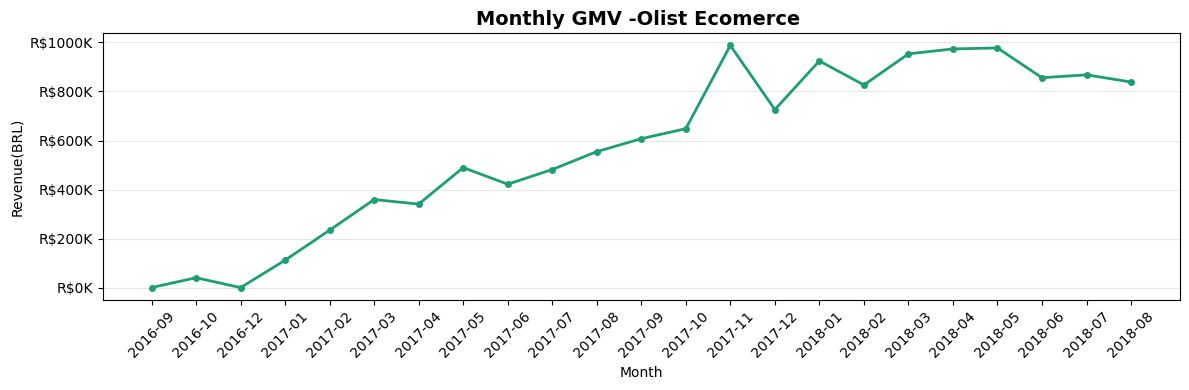

In [9]:
fig,ax = plt.subplots(figsize=(12,4) )
ax.plot(Monthly_revenue["order_month"].astype(str),
        Monthly_revenue["revenue"],
        color="#1D9E75",linewidth = 2,marker ="o",markersize = 4)
ax.set_title("Monthly GMV -Olist Ecomerce ", fontsize =14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue(BRL)")
ax.tick_params(axis ="x", rotation =45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"R${x/1000:.0f}K"))
ax.grid(axis= "y" ,alpha = 0.3)
plt.tight_layout()
plt.show()

In [10]:
os.makedirs("../data/processed", exist_ok=True) 
df.to_csv("../data/processed/orders_items_merged.csv", index=False)
print("Saved! Rows:", len(df))

Saved! Rows: 112650
